In [80]:
#preserved concepts
import concept_getters
import pandas as pd
import re
import os
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]
expl_clus=3
import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

In [81]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
        
unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [82]:
list_of_repeated_concepts = set()

for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'reordered' is not defined

In [83]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

0

In [84]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

NameError: name 'reordered' is not defined

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

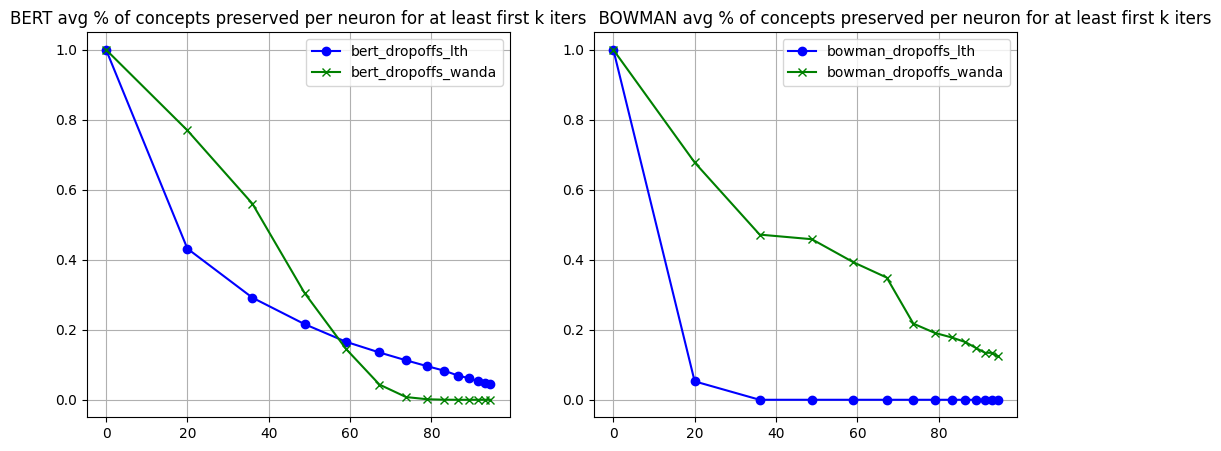

In [85]:
import matplotlib.pyplot as plt

def get_num_concpets_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
        
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    
    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def get_sparsities(model, method, filename):
    li=[]
    for s in sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/")):
        if '.ipy' in s: continue
        li.append(float(s.split("%")[0]))
    return li

x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT avg % of concepts preserved per neuron for at least first k iters')
axs[0].legend()
axs[0].grid(True)



model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'


sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                      BOWMAN avg % of concepts preserved per neuron for at least first k iters')
axs[1].legend()
axs[1].grid(True)
    
    

#so ex 30% of concepts make it to the 3rd pruning iter staying with the same neuron
    
  

# % of neurons that preserve concepts for at lesat first k iters

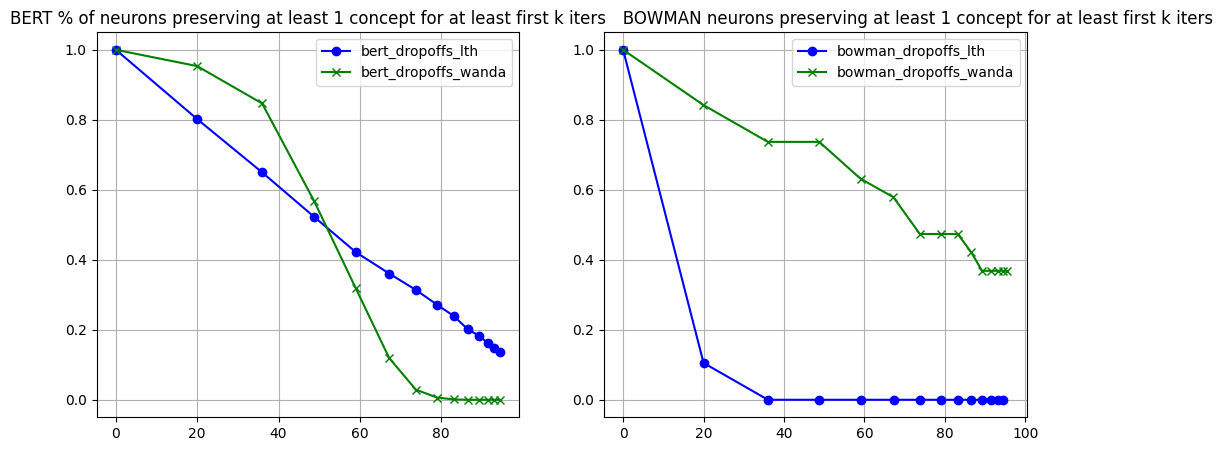

In [55]:
import torch
def get_neurons_explained_originally(model, method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


    
    
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT % of neurons preserving at least 1 concept for at least first k iters')
axs[0].legend()
axs[0].grid(True)




model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list_l = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_l)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'
sparsity_list_w = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_w)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[1].plot(sparsity_list_l, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(sparsity_list_w, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                       BOWMAN neurons preserving at least 1 concept for at least first k iters')
axs[1].legend()
axs[1].grid(True)



#65% of neurons preserve concepts for at least 3 pruning iters

# global overlap: % of concepts that are preserved in kth pruning iter compared to original

412 412
343 482
322 498
285 499
250 501
176 463
120 441
105 450
90 438
134 455
119 445
103 442
74 440
58 437
412 412
298 529
306 542
284 545
294 527
280 556
288 551
278 550
282 534
278 528
281 517
282 514
265 511
269 504
26 26
20 39
19 40
19 42
19 44
16 47
18 44
21 47
19 48
18 44
17 46
18 51
20 45
17 48
14 53
26 26
20 54
20 60
18 53
17 57
19 63
18 58
19 72
15 84
17 78
19 74
16 86
18 79
16 108


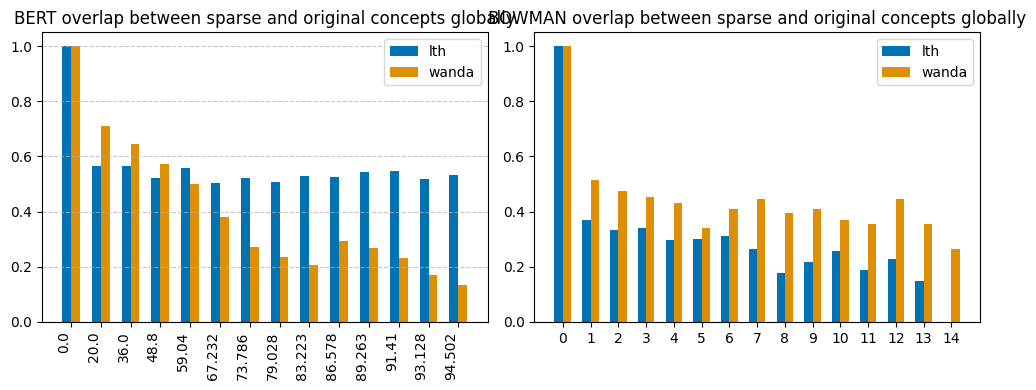

In [56]:
import os
import matplotlib.pyplot as plt
import numpy as np

def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations
def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union)
    return intersection / union if union > 0 else 0



fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

method='wanda'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
    
    
method='wanda'
filename='Run1'
model='BOWMAN'
        
x_w=get_sparsities(model, method, filename)
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars

global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run1'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x=get_sparsities(model, method, filename)
x_pos_l = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# First plot
axs[0].bar(x_pos_l - bar_width/2, bert_overlap_between_sparse_and_base_lth, label='lth', color='#0173b2', width=bar_width)
axs[0].bar(x_pos_l + bar_width/2, bert_overlap_between_sparse_and_base_wanda, label='wanda', color='#de8f05', width=bar_width)
axs[0].set_title('BERT overlap between sparse and original concepts globally')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x, rotation=90, ha='right')

# Second plot
axs[1].bar(x_pos_l- bar_width/2, bowman_overlap_between_sparse_and_base_lth, label='lth',color='#0173b2', width=bar_width)
axs[1].bar(x_pos_w+bar_width/2, bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='#de8f05', width=bar_width)
axs[1].set_title('BOWMAN overlap between sparse and original concepts globally')
axs[1].set_xticks(x_pos_w)
axs[1].legend()

plt.tight_layout()
plt.show()


[Text(0, 0, '0.0'),
 Text(1, 0, '19.971'),
 Text(2, 0, '35.986'),
 Text(3, 0, '48.779'),
 Text(4, 0, '59.033'),
 Text(5, 0, '67.188'),
 Text(6, 0, '73.779'),
 Text(7, 0, '79.004'),
 Text(8, 0, '83.203'),
 Text(9, 0, '86.572'),
 Text(10, 0, '89.258'),
 Text(11, 0, '91.406'),
 Text(12, 0, '93.115'),
 Text(13, 0, '94.482'),
 Text(14, 0, '95.557')]

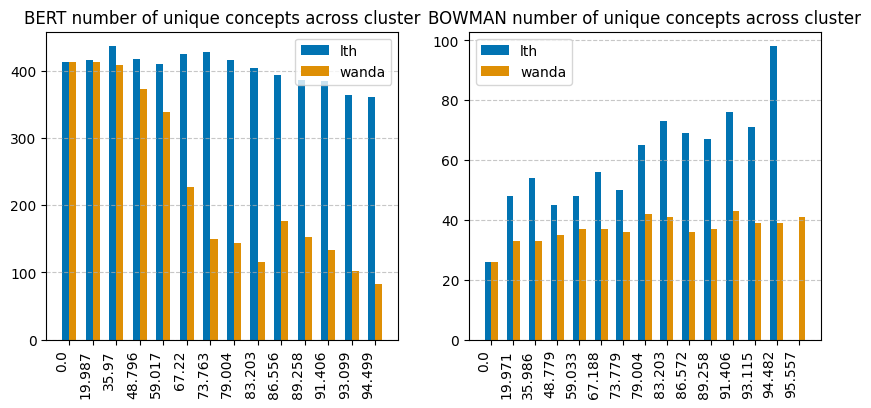

In [34]:
def get_number_of_unique_concepts_global(df):
    concepts=set()
    for neuron,expls in get_indiv_concepts_per_unit(df).items():
        concepts.update(expls)
    return len(concepts)

def get_num_concepts_across_cluster(model, method, filename):
    explanations = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        num_unique = get_number_of_unique_concepts_global(cluster3_expls)
        explanations.append(num_unique)
    return explanations
import numpy as np

fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns


bar_width = 0.3

model='BERT'
method='lottery_ticket'
filename='Run2Full'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BERT'        
method='wanda'
filename='Run2Full'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[0].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)


axs[0].set_title('BERT number of unique concepts across cluster')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x_axis, rotation=90, ha='right')

model='BOWMAN'
method='lottery_ticket'
filename='Run1'
x=get_sparsities(model, method, filename)
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[1].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BOWMAN'        
method='wanda'
filename='Run1'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[1].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BOWMAN number of unique concepts across cluster')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(x_axis, rotation=90, ha='right')


In [ ]:
#every iteration is 55% similar to the concepts in the original
#with wanda its expectedly reducing in similar (wb increase at 86)

# globally: % of concepts preserved in kth pruning iter compared to the one prior to it 

412 412
343 482
329 492
291 489
252 459
183 383
116 260
83 209
75 184
81 212
115 214
99 186
68 167
57 128
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
412 412
298 529
314 537
319 534
307 519
296 537
311 540
300 543
290 530
301 497
291 489
289 481
275 473
273 452
26 26
20 39
25 41
26 42
28 44
28 46
27 46
30 48
30 53
29 48
25 48
29 51
25 57
25 53
26 54
26 26
20 54
26 76
19 80
22 71
26 78
25 81
28 87
27 111
32 110
36 100
30 113
36 111
43 126


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '0.0/19.971'),
 Text(2, 0, '19.971/35.986'),
 Text(3, 0, '35.986/48.779'),
 Text(4, 0, '48.779/59.033'),
 Text(5, 0, '59.033/67.188'),
 Text(6, 0, '67.188/73.779'),
 Text(7, 0, '73.779/79.004'),
 Text(8, 0, '79.004/83.203'),
 Text(9, 0, '83.203/86.572'),
 Text(10, 0, '86.572/89.258'),
 Text(11, 0, '89.258/91.406'),
 Text(12, 0, '91.406/93.115'),
 Text(13, 0, '93.115/94.482'),
 Text(14, 0, '94.482/95.557')]

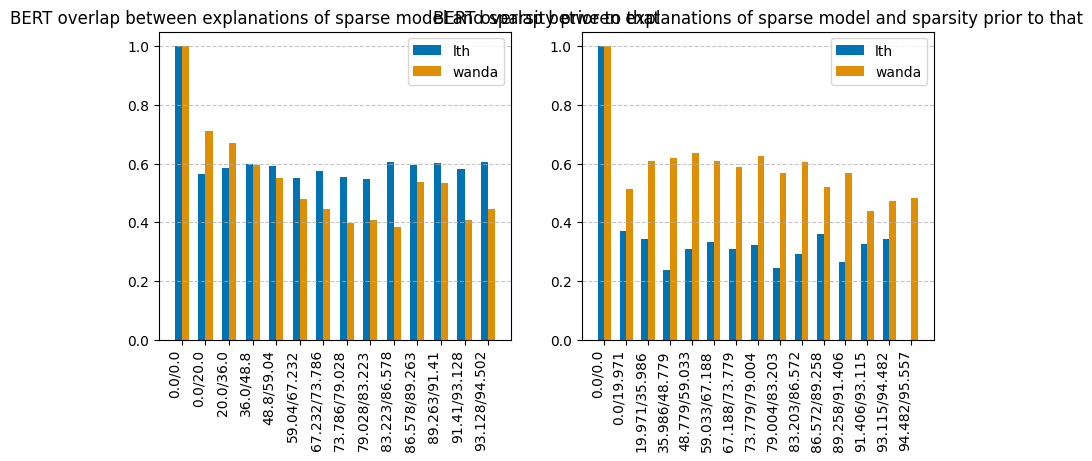

In [39]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union)
    return intersection / union if union > 0 else 0


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     

x_axis=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j+1]}" for j in range(len(x_axis) - 1)]        
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')


model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)
x_axis_w=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        

x_axis_l=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j+1]}" for j in range(len(x_axis_l) - 1)]        
x_pos_l = np.arange(len(x))  # Numeric positions for bars

   
x = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j+1]}" for j in range(len(x_axis_w) - 1)]        
x_pos_w = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x, rotation=90, ha='right')

# global overlap: % of concepts in prev that carry over to next

cur= 0.0, pre= 0 
cur= 19.987, pre= 0.0 
cur= 35.97, pre= 19.987 
cur= 48.796, pre= 35.97 
cur= 59.017, pre= 48.796 
cur= 67.22, pre= 59.017 
cur= 73.763, pre= 67.22 
cur= 79.004, pre= 73.763 
cur= 83.203, pre= 79.004 
cur= 86.556, pre= 83.203 
cur= 89.258, pre= 86.556 
cur= 91.406, pre= 89.258 
cur= 93.099, pre= 91.406 
cur= 94.499, pre= 93.099 
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
412 412
298 529
314 537
319 534
307 519
296 537
311 540
300 543
290 530
301 497
291 489
289 481
275 473
273 452
26 26
20 39
25 41
26 42
28 44
28 46
27 46
30 48
30 53
29 48
25 48
29 51
25 57
25 53
26 54
26 26
20 54
26 76
19 80
22 71
26 78
25 81
28 87
27 111
32 110
36 100
30 113
36 111
43 126


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '19.971/0.0'),
 Text(2, 0, '35.986/19.971'),
 Text(3, 0, '48.779/35.986'),
 Text(4, 0, '59.033/48.779'),
 Text(5, 0, '67.188/59.033'),
 Text(6, 0, '73.779/67.188'),
 Text(7, 0, '79.004/73.779'),
 Text(8, 0, '83.203/79.004'),
 Text(9, 0, '86.572/83.203'),
 Text(10, 0, '89.258/86.572'),
 Text(11, 0, '91.406/89.258'),
 Text(12, 0, '93.115/91.406'),
 Text(13, 0, '94.482/93.115'),
 Text(14, 0, '95.557/94.482')]

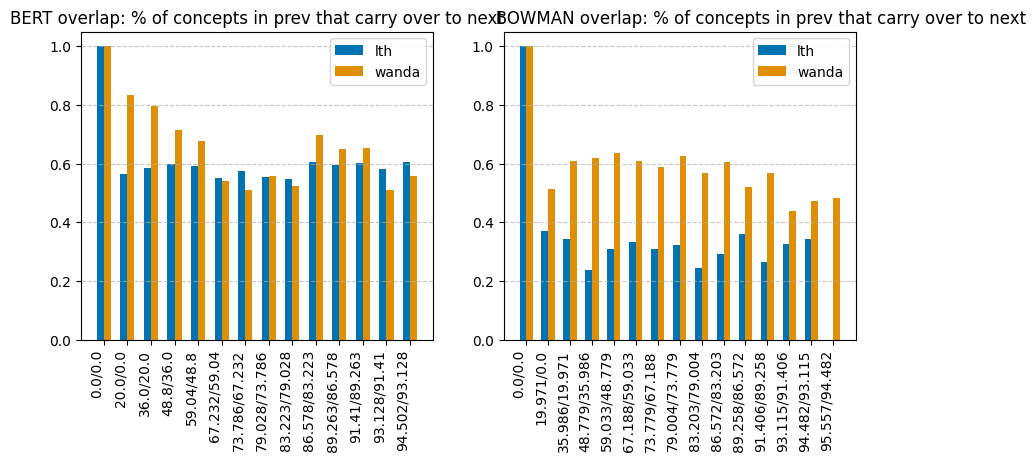

In [62]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def entailement(cur, prev):
    ct=0
    for i in prev:
        if i in cur:
            ct +=1
    return ct/len(prev)


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    
    if i-1 >= 0:
        
        print(f"cur= {sparsity}, pre= {sps[i-1]} ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        print(f"cur= {sparsity}, pre= 0 ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity],base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     
model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
x_axis_w=get_sparsities(model, method, filename)       
x_w = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j-1]}" for j in range(1,len(x_axis_w))]        
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars
 

model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >=0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x_axis_l=get_sparsities(model, method, filename)       
x_l = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j-1]}" for j in range(1,len(x_axis_l))]        
x_pos_l = np.arange(len(x_l))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap: % of concepts in prev that carry over to next')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x_l, rotation=90, ha='right')



axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('                               BOWMAN overlap: % of concepts in prev that carry over to next')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x_w, rotation=90, ha='right')

In [ ]:
#every subseq iteration has rougly 60% of concepts preserved fromthe prev iter lthbert

#bowman 30% overlap between subseq pruning iters
bowman looses more concepts with pruning? or at least it doesnt preserve concepts as bert does cuz global overalp is very low
and locally after pruning % of concepts preserved drastially drops